# Disease Prediction Model - Model Selection and Training

## 1. Loading the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, ConfusionMatrixDisplay
)

from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

### 1.1 Loading transformed datasets

In [2]:
root = Path().resolve().parent

diabetes_path = root / "data" / "processed" / "diabetes_transformed.csv"
df_diabetes = pd.read_csv(diabetes_path)

hypertension_path = root / "data" / "processed" / "hypertension_transformed.csv"
df_hypertension = pd.read_csv(hypertension_path)

heart_path = root / "data" / "processed" / "heart_disease_transformed.csv"
df_heart = pd.read_csv(heart_path)

### 1.2 Loading scalers and encoders

In [3]:
diabetes_scaler_path = root / "models" / "preprocessors" / "scalers" / "diabetes_scaler.pkl"
diabetes_scaler = joblib.load(diabetes_scaler_path)

hypertension_scaler_path = root / "models" / "preprocessors" / "scalers" / "hypertension_scaler.pkl"
hypertension_scaler = joblib.load(hypertension_scaler_path)

heart_scaler_path = root / "models" / "preprocessors" / "scalers" / "heart_scaler.pkl"
heart_scaler = joblib.load(heart_scaler_path)

metabolic_index_scaler_path = root / "models" / "preprocessors" / "scalers" / "metabolic_index_scaler.pkl"
metabolic_index_scaler = joblib.load(metabolic_index_scaler_path)

metabolic_syndrome_scaler_path = root / "models" / "preprocessors" / "scalers" / "metabolic_syndrome_scaler.pkl"
metabolic_syndrome_scaler = joblib.load(metabolic_syndrome_scaler_path);

In [4]:
diabetes_gender_encoder_path = root / "models" / "preprocessors" / "encoders" / "diabetes_gender_encoder.pkl"
diabetes_gender_encoder = joblib.load(diabetes_gender_encoder_path)

diabetes_smoking_encoder_path = root / "models" / "preprocessors" / "encoders" / "diabetes_smoking_encoder.pkl"
diabetes_smoking_encoder = joblib.load(diabetes_smoking_encoder_path)

hypertension_encoders_path = root / "models" / "preprocessors" / "encoders" / "hypertension_encoders.pkl"
hypertension_encoders = joblib.load(hypertension_encoders_path)

heart_gender_encoder_path = root / "models" / "preprocessors" / "encoders" / "heart_gender_encoder.pkl"
heart_gender_encoder = joblib.load(heart_gender_encoder_path)

### 1.3 Helper functions

Helper function to directly display the confusion matrix metrics from a model's test results

In [5]:
def get_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "precision": tp/(tp+fp),
        "recall": tp/(tp+fn),
        "sensitivity": tp/(tp+fn),
        "specificity": tn/(tn+fp)
    }

## 2. Diabetes Model

### 2.1 Analyzing the dataset

In [6]:
df_diabetes.head()

,age,bmi,hba1c_level,blood_glucose_level,metabolic_index,gender,smoking_history,diabetes
0,1.365999,-0.462589,1.055750,0.637258,0.410140,0,2,1
1,0.580004,-0.281327,0.273000,-0.097820,-0.035382,0,2,0
2,-0.390931,-0.256610,0.351275,-0.325344,-0.076893,0,2,0
3,-0.714576,-0.281327,-0.901126,-1.112927,-0.765127,0,2,0
4,-0.853281,-0.281327,-1.292501,-1.287946,-0.953925,1,2,0


In [7]:
FEATURE_COLS = [x for x in df_diabetes.columns if x != "diabetes"]
TARGET_COL = "diabetes"
print(FEATURE_COLS)

['age', 'bmi', 'hba1c_level', 'blood_glucose_level', 'metabolic_index', 'gender', 'smoking_history']


### 2.2 Train-Test Split

We will go with a 80/20 train-test split

In [8]:
X = df_diabetes[FEATURE_COLS]
y = df_diabetes[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size : {X_train.shape[0]}")
print(f"Test set size     : {X_test.shape[0]}")
print(f"\nTarget distribution in training set:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nTarget distribution in test set:\n{y_test.value_counts(normalize=True).round(3)}")

Training set size : 8000
Test set size     : 2000

Target distribution in training set:
diabetes
0    0.5
1    0.5
Name: proportion, dtype: float64

Target distribution in test set:
diabetes
0    0.5
1    0.5
Name: proportion, dtype: float64


Stratified split ensures that both sets get the same distribution of classes, i.e. the ratio of classes is same in both sets.

### 2.3 Model Training and Selection

We will try three classifiers:
* Logistic Regression
* Random Forest
* Gradient Boosting

In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")
    cv_results[name] = scores
    print(f"{name:25s}  CV ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}")

Logistic Regression        CV ROC-AUC: 0.9608 ± 0.0044
Random Forest              CV ROC-AUC: 0.9727 ± 0.0040
Gradient Boosting          CV ROC-AUC: 0.9774 ± 0.0030


Now we can evaluate all models using 5-fold stratified cross-validation before final evalutation.

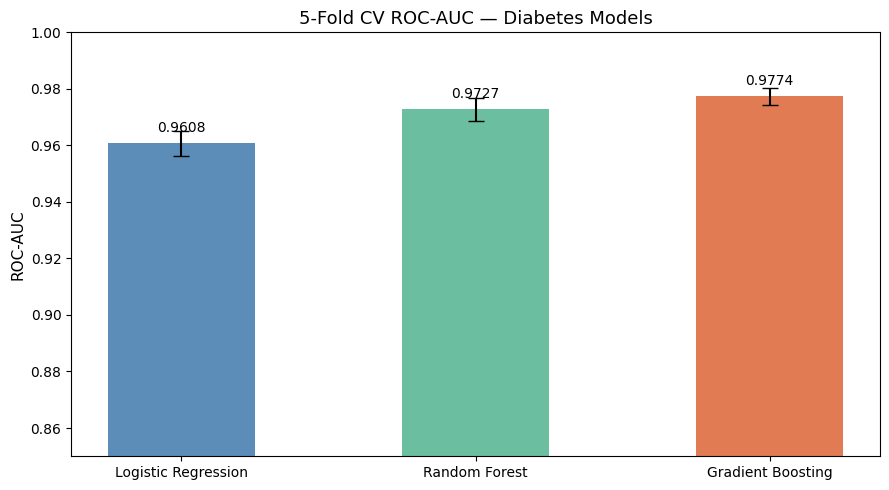

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))

names  = list(cv_results.keys())
means  = [v.mean() for v in cv_results.values()]
stds   = [v.std()  for v in cv_results.values()]
colors = ["#5B8DB8", "#6BBFA0", "#E07B54"]

bars = ax.bar(names, means, yerr=stds, capsize=6, color=colors, width=0.5)
ax.set_ylim(0.85, 1.0)
ax.set_ylabel("ROC-AUC", fontsize=11)
ax.set_title("5-Fold CV ROC-AUC — Diabetes Models", fontsize=13)

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{mean:.4f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig(root / "plots" / "diabetes_cv_comparison.png", dpi=120)
plt.show()

### 2.4 Final Model Evaluation

Based on the cross-validation results, we can now select the best performing model to train fully and evaluate on the test set.

In [11]:
best_name = max(cv_results, key=lambda k: cv_results[k].mean())
best_model = models[best_name]

print(f"Selected model: {best_name}")

best_model.fit(X_train, y_train)

y_pred      = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)[:, 1]

acc     = accuracy_score(y_test, y_pred)
f1      = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"\nTest Set Results — {best_name}")
print(f"  Accuracy : {acc:.4f}")
print(f"  F1 Score : {f1:.4f}")
print(f"  ROC-AUC  : {roc_auc:.4f}")

Selected model: Gradient Boosting

Test Set Results — Gradient Boosting
  Accuracy : 0.9175
  F1 Score : 0.9182
  ROC-AUC  : 0.9798


### 2.5 Visualizing Performance

#### 2.5.1 Confusion Matrix

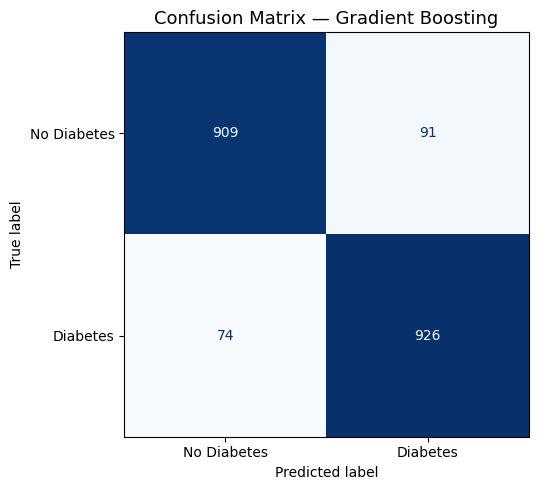

Precision :  91.05
Recall :  92.6
Sensitivity :  92.6
Specificity :  90.9


In [12]:
fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Diabetes", "Diabetes"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")

ax.set_title(f"Confusion Matrix — {best_name}", fontsize=13)
plt.tight_layout()
plt.savefig(root / "plots" / "diabetes_confusion_matrix.png", dpi=120)
plt.show()

metrics = get_metrics(y_test, y_pred)
for m in metrics:
    print(m.title(), ": ", round(metrics[m]*100, 2))

From the above confusion matrix, we can infer that the model has a good amount of **true predictions**.
However about 3.7% of false negatives are present, which could be a problem as in real-world healthcare settings we would rather get a false positive than a false negative. So, in order to achieve this we will choose to sacrifice some accuracy in order to get lesser number of false negatives.

In [13]:
THRESHOLD = 0.3
y_pred_prob = best_model.predict_proba(X_test)[:, 1]
y_pred      = (y_pred_prob >= THRESHOLD).astype(int)


acc     = accuracy_score(y_test, y_pred)
f1      = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"\nTest Set Results — {best_name}")
print(f"  Accuracy : {acc:.4f}")
print(f"  F1 Score : {f1:.4f}")
print(f"  ROC-AUC  : {roc_auc:.4f}")


Test Set Results — Gradient Boosting
  Accuracy : 0.9070
  F1 Score : 0.9123
  ROC-AUC  : 0.9798


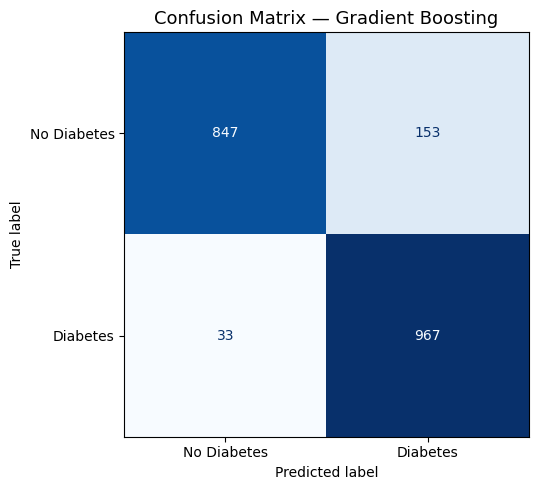

Precision :  86.34
Recall :  96.7
Sensitivity :  96.7
Specificity :  84.7


In [14]:
fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Diabetes", "Diabetes"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")

ax.set_title(f"Confusion Matrix — {best_name}", fontsize=13)
plt.tight_layout()
plt.savefig(root / "plots" / "diabetes_confusion_matrix.png", dpi=120)
plt.show()

metrics = get_metrics(y_test, y_pred)
for m in metrics:
    print(m.title(), ": ", round(metrics[m]*100, 2))

#### 2.5.2 ROC Curve

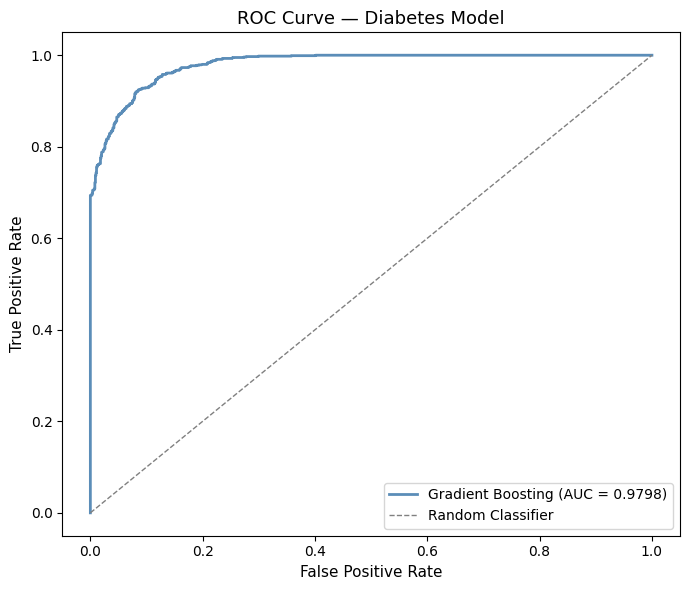

In [15]:
fig, ax = plt.subplots(figsize=(7, 6))

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

ax.plot(fpr, tpr, color="#5B8DB8", lw=2, label=f"{best_name} (AUC = {roc_auc:.4f})")
ax.plot([0, 1], [0, 1], color="grey", linestyle="--", lw=1, label="Random Classifier")

ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("ROC Curve — Diabetes Model", fontsize=13)
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig(root / "plots" / "diabetes_roc_curve.png", dpi=120)
plt.show()

#### 2.5.3 Feature Importance

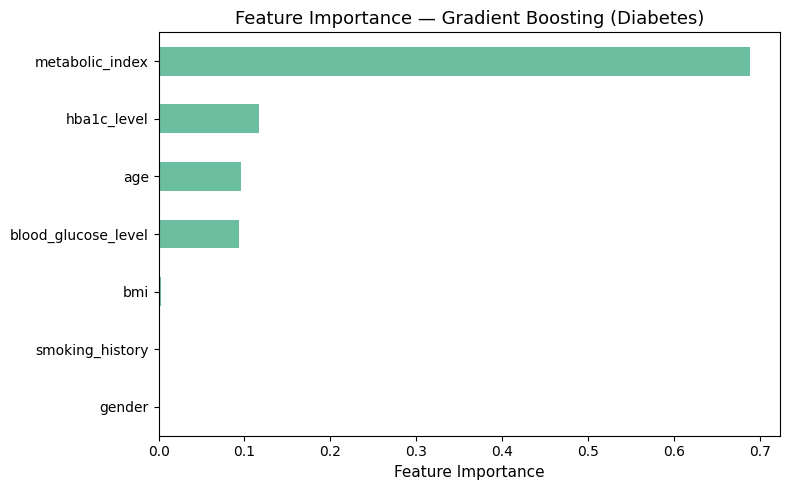

In [16]:
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
    importance_label = "Feature Importance"
else:
    importances = np.abs(best_model.coef_[0])
    importance_label = "Absolute Coefficient"

feat_imp = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
feat_imp.plot(kind="barh", ax=ax, color="#6BBFA0")

ax.set_xlabel(importance_label, fontsize=11)
ax.set_title(f"Feature Importance — {best_name} (Diabetes)", fontsize=13)

plt.tight_layout()
plt.savefig(root / "plots" / "diabetes_feature_importance.png", dpi=120)
plt.show()

As expected, the engineered feature **metabolic_index** dominates the model, and other important features like **age** and **blood_glucose_level** also contribute quite a bit. Interestingly however, the model relies very less on the **bmi** feature which seems counterintuitive, but this is most likely due to the metabolic index feature being derived from the BMI feature hence BMI actually doesn't give any new information to the model.

### 2.6 Saving the Model

In [20]:
diabetes_model_path = root / "models" / "trained" / "diabetes_model.pkl"
joblib.dump(best_model, diabetes_model_path)
print(f"Saved: {diabetes_model_path}")

Saved: /home/anush/Documents/GitHub/DSProject2/models/trained/diabetes_model.pkl


## 3. Hypertension Model

### 3.1 Analyzing the dataset

In [21]:
df_hypertension.head()

,age,salt_intake,stress_score,sleep_duration,bmi,lifestyle_risk_score,bp_history,medication,family_history,exercise_level,smoking_status,has_hypertension
0,0.959963,-0.266590,1.279847,-0.033883,-0.047723,1.2000,1,3,1,1,0,1
1,-0.943609,1.588600,1.598165,-0.682468,-0.579671,1.3250,1,3,0,1,0,0
2,1.422994,0.485514,-0.630061,0.420126,-1.621403,0.1125,1,3,0,2,0,0
3,-0.634921,0.736216,1.598165,-1.460769,-0.867810,1.4750,0,0,0,1,0,1
4,-0.480578,0.635935,-1.266698,-0.423034,-2.175515,0.2750,2,4,0,2,0,0


In [22]:
HYPERTENSION_FEATURE_COLS = [x for x in df_hypertension.columns if x != "has_hypertension"]
HYPERTENSION_TARGET_COL = "has_hypertension"
print(HYPERTENSION_FEATURE_COLS)

['age', 'salt_intake', 'stress_score', 'sleep_duration', 'bmi', 'lifestyle_risk_score', 'bp_history', 'medication', 'family_history', 'exercise_level', 'smoking_status']


### 3.2 Train-Test Split

We will go with a 80/20 train-test split

In [23]:
X_h = df_hypertension[HYPERTENSION_FEATURE_COLS]
y_h = df_hypertension[HYPERTENSION_TARGET_COL]

X_h_train, X_h_test, y_h_train, y_h_test = train_test_split(
    X_h, y_h, test_size=0.2, random_state=42, stratify=y_h
)

print(f"Training set size : {X_h_train.shape[0]}")
print(f"Test set size     : {X_h_test.shape[0]}")
print(f"\nTarget distribution in training set:\n{y_h_train.value_counts(normalize=True).round(3)}")
print(f"\nTarget distribution in test set:\n{y_h_test.value_counts(normalize=True).round(3)}")

Training set size : 1588
Test set size     : 397

Target distribution in training set:
has_hypertension
1    0.52
0    0.48
Name: proportion, dtype: float64

Target distribution in test set:
has_hypertension
1    0.519
0    0.481
Name: proportion, dtype: float64


Stratified split ensures that both sets get the same distribution of classes, i.e. the ratio of classes is same in both sets.

### 3.3 Model Training and Selection

We will try the same three classifiers as the diabetes model for consistency:
* Logistic Regression
* Random Forest
* Gradient Boosting

In [24]:
hypertension_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, random_state=42),
}

cv_h = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_h_results = {}

for name, model in hypertension_models.items():
    scores = cross_val_score(model, X_h_train, y_h_train, cv=cv_h, scoring="roc_auc")
    cv_h_results[name] = scores
    print(f"{name:25s}  CV ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}")

Logistic Regression        CV ROC-AUC: 0.9076 ± 0.0166
Random Forest              CV ROC-AUC: 0.9953 ± 0.0011
Gradient Boosting          CV ROC-AUC: 0.9993 ± 0.0006


Now we can evaluate all models using 5-fold stratified cross-validation before final evaluation.

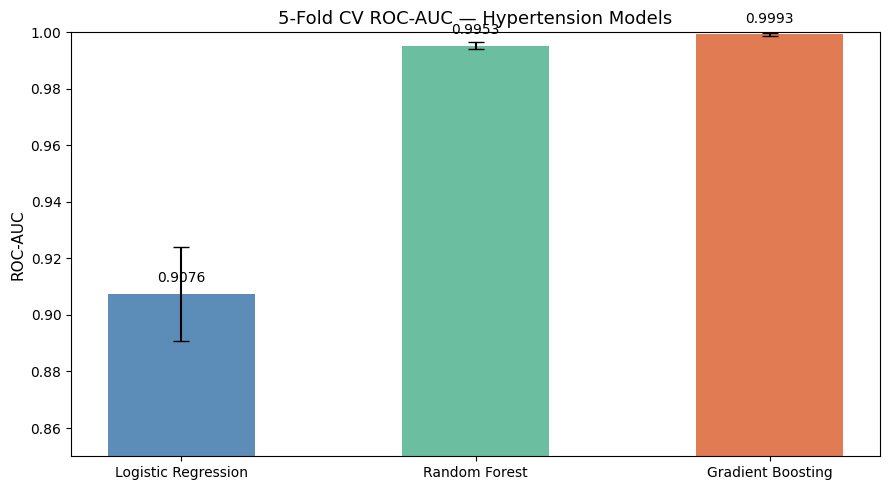

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))

names_h  = list(cv_h_results.keys())
means_h  = [v.mean() for v in cv_h_results.values()]
stds_h   = [v.std()  for v in cv_h_results.values()]
colors   = ["#5B8DB8", "#6BBFA0", "#E07B54"]

bars = ax.bar(names_h, means_h, yerr=stds_h, capsize=6, color=colors, width=0.5)
ax.set_ylim(0.85, 1.0)
ax.set_ylabel("ROC-AUC", fontsize=11)
ax.set_title("5-Fold CV ROC-AUC — Hypertension Models", fontsize=13)

for bar, mean in zip(bars, means_h):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{mean:.4f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig(root / "plots" / "hypertension_cv_comparison.png", dpi=120)
plt.show()

### 3.4 Final Model Evaluation

Based on the cross-validation results, we can now select the best performing model to train fully and evaluate on the test set.

In [26]:
best_h_name = max(cv_h_results, key=lambda k: cv_h_results[k].mean())
best_h_model = hypertension_models[best_h_name]

print(f"Selected model: {best_h_name}")

best_h_model.fit(X_h_train, y_h_train)

y_h_pred      = best_h_model.predict(X_h_test)
y_h_pred_prob = best_h_model.predict_proba(X_h_test)[:, 1]

acc_h     = accuracy_score(y_h_test, y_h_pred)
f1_h      = f1_score(y_h_test, y_h_pred)
roc_auc_h = roc_auc_score(y_h_test, y_h_pred_prob)

print(f"\nTest Set Results — {best_h_name}")
print(f"  Accuracy : {acc_h:.4f}")
print(f"  F1 Score : {f1_h:.4f}")
print(f"  ROC-AUC  : {roc_auc_h:.4f}")

Selected model: Gradient Boosting

Test Set Results — Gradient Boosting
  Accuracy : 0.9723
  F1 Score : 0.9732
  ROC-AUC  : 0.9981


### 3.5 Visualizing Performance

#### 3.5.1 Confusion Matrix

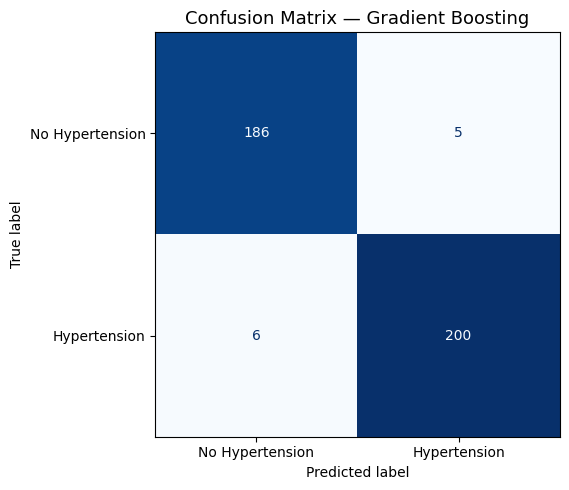

Precision :  97.56
Recall :  97.09
Sensitivity :  97.09
Specificity :  97.38


In [27]:
fig, ax = plt.subplots(figsize=(6, 5))

cm_h = confusion_matrix(y_h_test, y_h_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_h, display_labels=["No Hypertension", "Hypertension"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")

ax.set_title(f"Confusion Matrix — {best_h_name}", fontsize=13)
plt.tight_layout()
plt.savefig(root / "plots" / "hypertension_confusion_matrix.png", dpi=120)
plt.show()

metrics_h = get_metrics(y_h_test, y_h_pred)
for m in metrics_h:
    print(m.title(), ": ", round(metrics_h[m]*100, 2))

Here, the false negative rate is relatively low, hence no need to adjust the threshold.

#### 3.5.2 ROC Curve

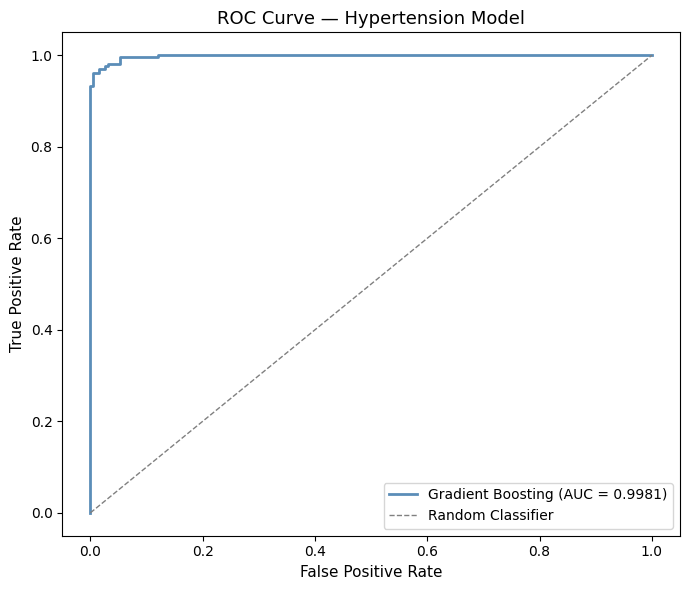

In [28]:
fig, ax = plt.subplots(figsize=(7, 6))

fpr_h, tpr_h, _ = roc_curve(y_h_test, y_h_pred_prob)

ax.plot(fpr_h, tpr_h, color="#5B8DB8", lw=2, label=f"{best_h_name} (AUC = {roc_auc_h:.4f})")
ax.plot([0, 1], [0, 1], color="grey", linestyle="--", lw=1, label="Random Classifier")

ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("ROC Curve — Hypertension Model", fontsize=13)
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig(root / "plots" / "hypertension_roc_curve.png", dpi=120)
plt.show()

#### 3.5.3 Feature Importance

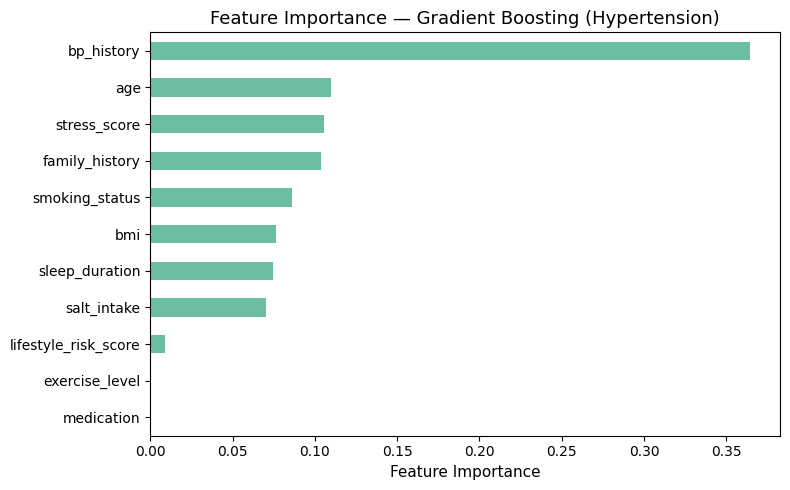

In [29]:
if hasattr(best_h_model, "feature_importances_"):
    importances_h = best_h_model.feature_importances_
    importance_label_h = "Feature Importance"
else:
    importances_h = np.abs(best_h_model.coef_[0])
    importance_label_h = "Absolute Coefficient"

feat_imp_h = pd.Series(importances_h, index=HYPERTENSION_FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
feat_imp_h.plot(kind="barh", ax=ax, color="#6BBFA0")

ax.set_xlabel(importance_label_h, fontsize=11)
ax.set_title(f"Feature Importance — {best_h_name} (Hypertension)", fontsize=13)

plt.tight_layout()
plt.savefig(root / "plots" / "hypertension_feature_importance.png", dpi=120)
plt.show()

As expected from our EDA, **bp_history** has the highest importance, which makes perfect sense as past history is a strong predictor in real life. Other features also show medium importance that fit with the expectations.

### 3.6 Saving the Model

In [30]:
hypertension_model_path = root / "models" / "trained" / "hypertension_model.pkl"
joblib.dump(best_h_model, hypertension_model_path)
print(f"Saved: {hypertension_model_path}")

Saved: /home/anush/Documents/GitHub/DSProject2/models/trained/hypertension_model.pkl


## 4. Heart Disease Model

The heart disease model is the final stage of our cascade architecture. The `diabetes` and `hypertension` columns in this dataset are float columns by design — at inference time they will receive predicted probabilities from the upstream diabetes and hypertension models rather than hard binary values. During training they hold `0.0` or `1.0` values, which trains the model to treat those columns as continuous signals.

### 4.1 Analyzing the dataset

In [31]:
df_heart.head()

,age,blood_pressure,cholesterol_level,diabetes,bmi,hypertension,sleep_hours,triglyceride_level,fasting_blood_sugar,crp_level,...,gender,smoking,family_heart_disease,low_hdl_cholesterol,high_ldl_cholesterol,exercise_habits,alcohol_consumption,stress_level,sugar_consumption,heart_disease_status
0,0.369061,0.184661,-1.618712,0.0,-0.648537,1.0,0.366591,1.049660,-0.006024,1.268241,...,1,1,1,1,0,3,3,2,2,0
1,1.084657,-0.214077,1.392213,1.0,-0.611996,0.0,1.001005,-1.354031,1.564643,0.434477,...,0,0,1,1,0,3,2,3,2,0
2,-0.181398,-1.353328,-0.216679,0.0,0.123523,0.0,-1.456907,1.636206,-1.194636,1.208400,...,1,0,0,1,1,1,1,1,1,0
3,-0.952040,-1.581178,1.553102,0.0,-0.785226,1.0,-0.994883,0.486115,-1.109735,1.162067,...,0,1,1,0,1,3,1,3,3,0
4,0.589244,0.925175,0.380910,1.0,-1.363683,1.0,0.022624,0.141087,1.437292,0.671158,...,1,1,1,0,0,1,1,3,3,0


In [32]:
HEART_FEATURE_COLS = [x for x in df_heart.columns if x != "heart_disease_status"]
HEART_TARGET_COL = "heart_disease_status"
print(HEART_FEATURE_COLS)

['age', 'blood_pressure', 'cholesterol_level', 'diabetes', 'bmi', 'hypertension', 'sleep_hours', 'triglyceride_level', 'fasting_blood_sugar', 'crp_level', 'homocysteine_level', 'inflammation_score', 'metabolic_syndrome_score', 'gender', 'smoking', 'family_heart_disease', 'low_hdl_cholesterol', 'high_ldl_cholesterol', 'exercise_habits', 'alcohol_consumption', 'stress_level', 'sugar_consumption']


### 4.2 Train-Test Split

We will go with a 80/20 train-test split. The heart disease dataset is slightly imbalanced (~10% difference between classes) as observed during EDA, so we use stratified splitting and apply class weights during training to counteract this.

In [34]:
X_hd = df_heart[HEART_FEATURE_COLS]
y_hd = df_heart[HEART_TARGET_COL]

X_hd_train, X_hd_test, y_hd_train, y_hd_test = train_test_split(
    X_hd, y_hd, test_size=0.2, random_state=42, stratify=y_hd
)

print(f"Training set size : {X_hd_train.shape[0]}")
print(f"Test set size     : {X_hd_test.shape[0]}")
print(f"\nTarget distribution in training set:\n{y_hd_train.value_counts(normalize=True).round(3)}")
print(f"\nTarget distribution in test set:\n{y_hd_test.value_counts(normalize=True).round(3)}")

Training set size : 8000
Test set size     : 2000

Target distribution in training set:
heart_disease_status
0    0.556
1    0.444
Name: proportion, dtype: float64

Target distribution in test set:
heart_disease_status
0    0.556
1    0.444
Name: proportion, dtype: float64


Stratified split ensures that both sets get the same distribution of classes, i.e. the ratio of classes is same in both sets.

### 4.3 Model Training and Selection

We use the same three classifiers. For the Random Forest and Gradient Boosting models, we set `class_weight="balanced"` to compensate for the slight class imbalance observed during EDA. Logistic Regression supports this natively as well.

In [35]:
heart_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced"),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, random_state=42),
}

cv_hd = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_hd_results = {}

for name, model in heart_models.items():
    scores = cross_val_score(model, X_hd_train, y_hd_train, cv=cv_hd, scoring="roc_auc")
    cv_hd_results[name] = scores
    print(f"{name:25s}  CV ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}")

Logistic Regression        CV ROC-AUC: 0.6749 ± 0.0177
Random Forest              CV ROC-AUC: 0.6608 ± 0.0074
Gradient Boosting          CV ROC-AUC: 0.6713 ± 0.0147


Now we can evaluate all models using 5-fold stratified cross-validation before final evaluation.

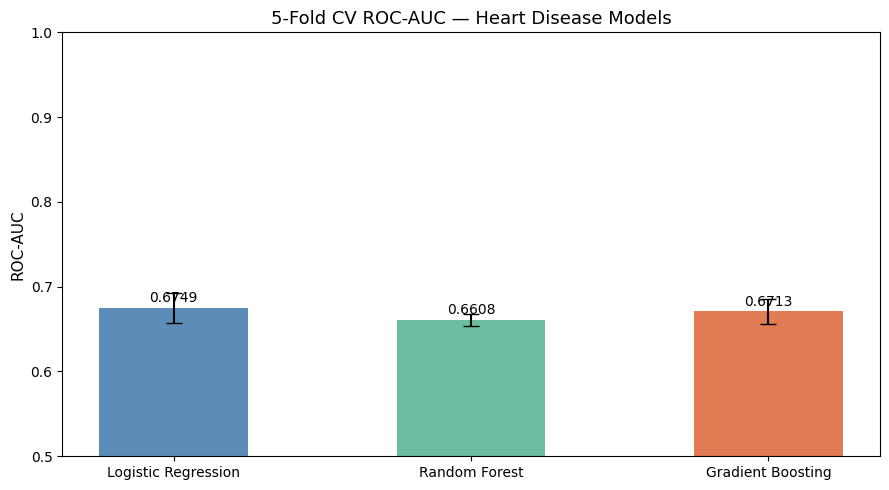

In [36]:
fig, ax = plt.subplots(figsize=(9, 5))

names_hd  = list(cv_hd_results.keys())
means_hd  = [v.mean() for v in cv_hd_results.values()]
stds_hd   = [v.std()  for v in cv_hd_results.values()]
colors    = ["#5B8DB8", "#6BBFA0", "#E07B54"]

bars = ax.bar(names_hd, means_hd, yerr=stds_hd, capsize=6, color=colors, width=0.5)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel("ROC-AUC", fontsize=11)
ax.set_title("5-Fold CV ROC-AUC — Heart Disease Models", fontsize=13)

for bar, mean in zip(bars, means_hd):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{mean:.4f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig(root / "plots" / "heart_cv_comparison.png", dpi=120)
plt.show()

Note: The y-axis starts at 0.5 here rather than 0.85 as in the other models, reflecting the fact that this dataset is synthetic and features have almost no separation between classes as observed during EDA. The model primarily relies on the `diabetes` and `hypertension` columns.

### 4.4 Final Model Evaluation

Based on the cross-validation results, we can now select the best performing model to train fully and evaluate on the test set.

In [37]:
best_hd_name = max(cv_hd_results, key=lambda k: cv_hd_results[k].mean())
best_hd_model = heart_models[best_hd_name]

print(f"Selected model: {best_hd_name}")

best_hd_model.fit(X_hd_train, y_hd_train)

y_hd_pred      = best_hd_model.predict(X_hd_test)
y_hd_pred_prob = best_hd_model.predict_proba(X_hd_test)[:, 1]

acc_hd     = accuracy_score(y_hd_test, y_hd_pred)
f1_hd      = f1_score(y_hd_test, y_hd_pred)
roc_auc_hd = roc_auc_score(y_hd_test, y_hd_pred_prob)

print(f"\nTest Set Results — {best_hd_name}")
print(f"  Accuracy : {acc_hd:.4f}")
print(f"  F1 Score : {f1_hd:.4f}")
print(f"  ROC-AUC  : {roc_auc_hd:.4f}")

Selected model: Logistic Regression

Test Set Results — Logistic Regression
  Accuracy : 0.6345
  F1 Score : 0.5990
  ROC-AUC  : 0.6924


### 4.5 Visualizing Performance

#### 4.5.1 Confusion Matrix

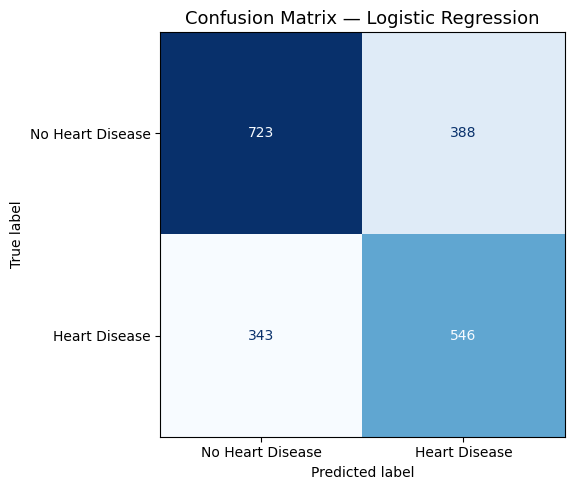

Precision :  58.46
Recall :  61.42
Sensitivity :  61.42
Specificity :  65.08


In [38]:
fig, ax = plt.subplots(figsize=(6, 5))

cm_hd = confusion_matrix(y_hd_test, y_hd_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_hd, display_labels=["No Heart Disease", "Heart Disease"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")

ax.set_title(f"Confusion Matrix — {best_hd_name}", fontsize=13)
plt.tight_layout()
plt.savefig(root / "plots" / "heart_confusion_matrix.png", dpi=120)
plt.show()

metrics_hd = get_metrics(y_hd_test, y_hd_pred)
for m in metrics_hd:
    print(m.title(), ": ", round(metrics_hd[m]*100, 2))

Given that this is a heart disease predictor, we once again prioritise recall over accuracy. Applying a lower decision threshold reduces the risk of missing true positive cases.

In [39]:
THRESHOLD_HD = 0.3
y_hd_pred      = (y_hd_pred_prob >= THRESHOLD_HD).astype(int)

acc_hd     = accuracy_score(y_hd_test, y_hd_pred)
f1_hd      = f1_score(y_hd_test, y_hd_pred)
roc_auc_hd = roc_auc_score(y_hd_test, y_hd_pred_prob)

print(f"\nTest Set Results — {best_hd_name} (Threshold = {THRESHOLD_HD})")
print(f"  Accuracy : {acc_hd:.4f}")
print(f"  F1 Score : {f1_hd:.4f}")
print(f"  ROC-AUC  : {roc_auc_hd:.4f}")


Test Set Results — Logistic Regression (Threshold = 0.3)
  Accuracy : 0.5960
  F1 Score : 0.6669
  ROC-AUC  : 0.6924


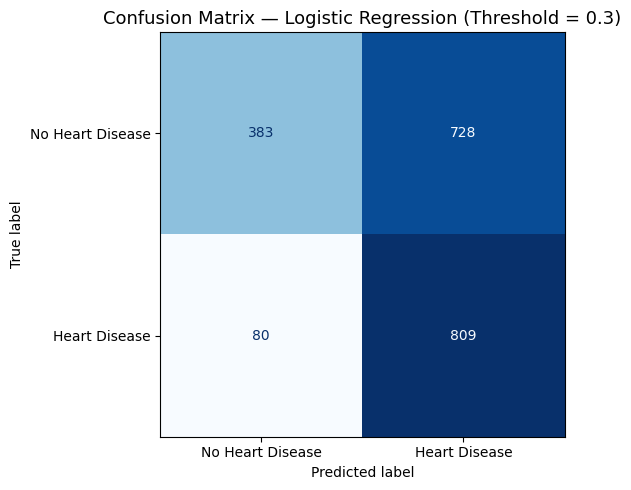

Precision :  52.64
Recall :  91.0
Sensitivity :  91.0
Specificity :  34.47


In [40]:
fig, ax = plt.subplots(figsize=(6, 5))

cm_hd = confusion_matrix(y_hd_test, y_hd_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_hd, display_labels=["No Heart Disease", "Heart Disease"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")

ax.set_title(f"Confusion Matrix — {best_hd_name} (Threshold = {THRESHOLD_HD})", fontsize=13)
plt.tight_layout()
plt.savefig(root / "plots" / "heart_confusion_matrix.png", dpi=120)
plt.show()

metrics_hd = get_metrics(y_hd_test, y_hd_pred)
for m in metrics_hd:
    print(m.title(), ": ", round(metrics_hd[m]*100, 2))

#### 4.5.2 ROC Curve

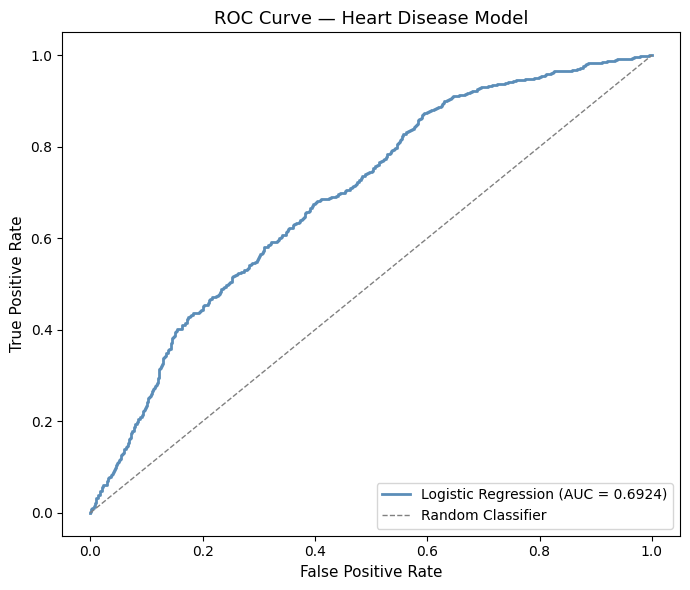

In [41]:
fig, ax = plt.subplots(figsize=(7, 6))

fpr_hd, tpr_hd, _ = roc_curve(y_hd_test, y_hd_pred_prob)

ax.plot(fpr_hd, tpr_hd, color="#5B8DB8", lw=2, label=f"{best_hd_name} (AUC = {roc_auc_hd:.4f})")
ax.plot([0, 1], [0, 1], color="grey", linestyle="--", lw=1, label="Random Classifier")

ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("ROC Curve — Heart Disease Model", fontsize=13)
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig(root / "plots" / "heart_roc_curve.png", dpi=120)
plt.show()

#### 4.5.3 Feature Importance

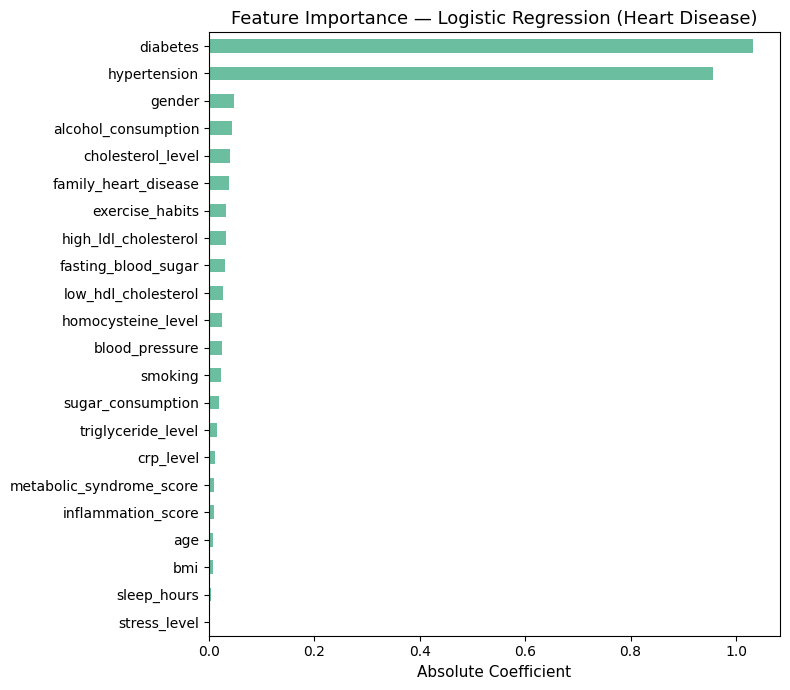

In [42]:
if hasattr(best_hd_model, "feature_importances_"):
    importances_hd = best_hd_model.feature_importances_
    importance_label_hd = "Feature Importance"
else:
    importances_hd = np.abs(best_hd_model.coef_[0])
    importance_label_hd = "Absolute Coefficient"

feat_imp_hd = pd.Series(importances_hd, index=HEART_FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
feat_imp_hd.plot(kind="barh", ax=ax, color="#6BBFA0")

ax.set_xlabel(importance_label_hd, fontsize=11)
ax.set_title(f"Feature Importance — {best_hd_name} (Heart Disease)", fontsize=13)

plt.tight_layout()
plt.savefig(root / "plots" / "heart_feature_importance.png", dpi=120)
plt.show()

The feature importance chart validates our cascade architecture — the `diabetes` and `hypertension` columns, which will receive probabilistic inputs at inference time, are expected to rank among the top features given the strong correlations observed during EDA.

### 4.6 Saving the Model

In [43]:
heart_model_path = root / "models" / "trained" / "heart_model.pkl"
joblib.dump(best_hd_model, heart_model_path)
print(f"Saved: {heart_model_path}")

Saved: /home/anush/Documents/GitHub/DSProject2/models/trained/heart_model.pkl


## 5. Model Comparison

A final side-by-side comparison of all three disease models across the key evaluation metrics.

In [44]:
comparison = pd.DataFrame({
    "Model":    ["Diabetes", "Hypertension", "Heart Disease"],
    "Accuracy": [accuracy_score(y_test,    y_pred),    accuracy_score(y_h_test, y_h_pred),    accuracy_score(y_hd_test, y_hd_pred)],
    "F1 Score": [f1_score(y_test,          y_pred),    f1_score(y_h_test,       y_h_pred),    f1_score(y_hd_test,       y_hd_pred)],
    "ROC-AUC":  [roc_auc_score(y_test,     y_pred_prob), roc_auc_score(y_h_test, y_h_pred_prob), roc_auc_score(y_hd_test, y_hd_pred_prob)],
    "Recall":   [
        get_metrics(y_test,    y_pred)["recall"],
        get_metrics(y_h_test,  y_h_pred)["recall"],
        get_metrics(y_hd_test, y_hd_pred)["recall"]
    ],
    "Classifier": [best_name, best_h_name, best_hd_name]
}).set_index("Model")

comparison.round(4)

,Accuracy,F1 Score,ROC-AUC,Recall,Classifier
Model,,,,,
Diabetes,0.9070,0.9123,0.9798,0.9670,Gradient Boosting
Hypertension,0.9723,0.9732,0.9981,0.9709,Gradient Boosting
Heart Disease,0.5960,0.6669,0.6924,0.9100,Logistic Regression


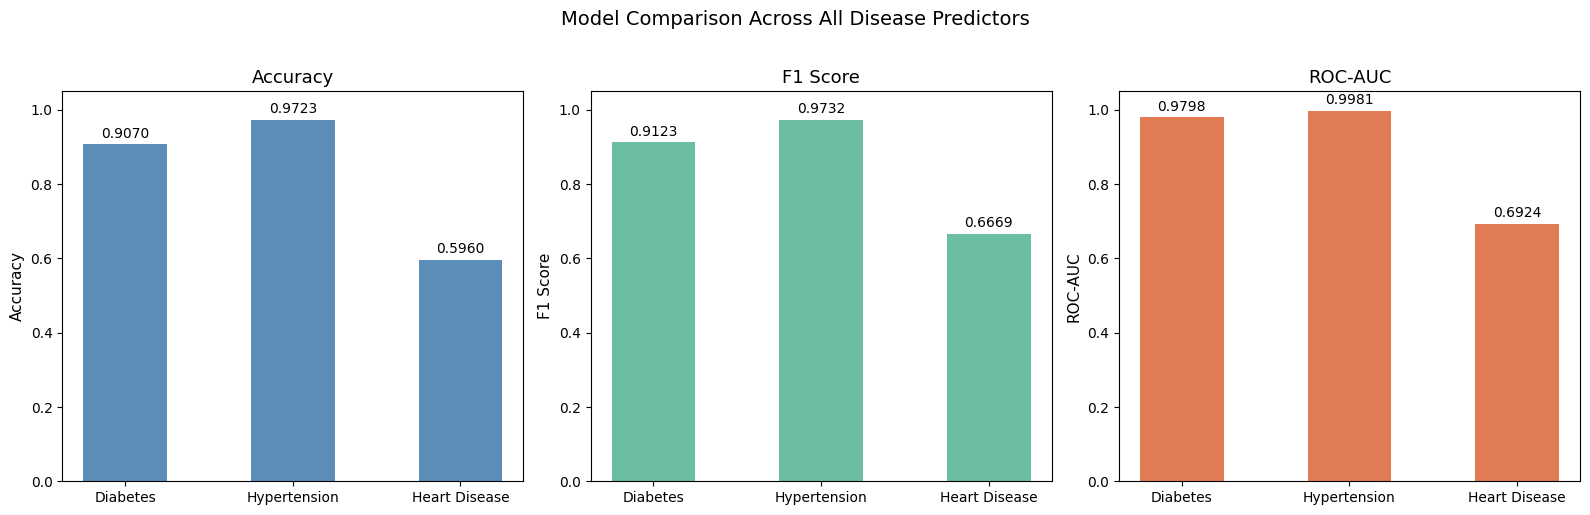

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics_to_plot = ["Accuracy", "F1 Score", "ROC-AUC"]
bar_color = ["#5B8DB8", "#6BBFA0", "#E07B54"]

for ax, metric, color in zip(axes, metrics_to_plot, bar_color):
    ax.bar(comparison.index, comparison[metric], color=color, width=0.5)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(metric, fontsize=13)

    for i, val in enumerate(comparison[metric]):
        ax.text(i, val + 0.01, f"{val:.4f}", ha="center", va="bottom", fontsize=10)

fig.suptitle("Model Comparison Across All Disease Predictors", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(root / "plots" / "model_comparison.png", dpi=120)
plt.show()

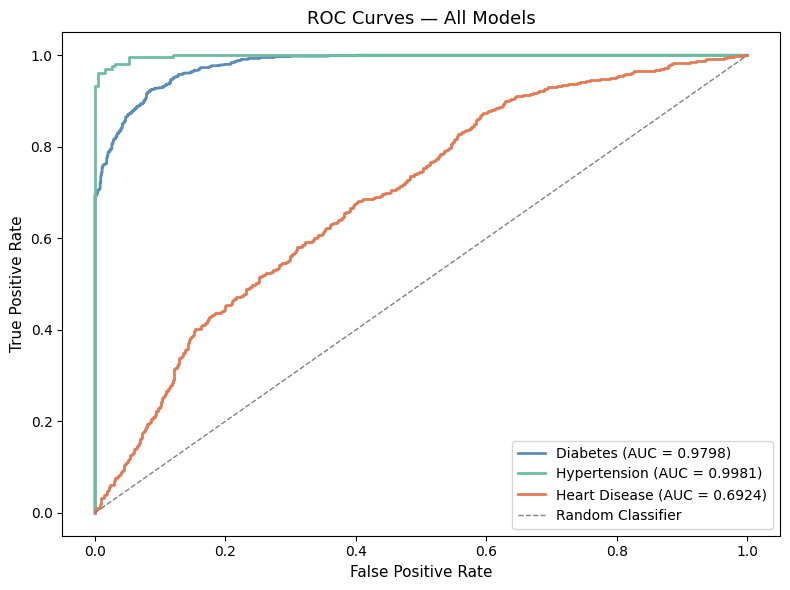

In [46]:
fig, ax = plt.subplots(figsize=(8, 6))

colors_roc = ["#5B8DB8", "#6BBFA0", "#E07B54"]
roc_data = [
    ("Diabetes",      fpr,    tpr,    roc_auc),
    ("Hypertension",  fpr_h,  tpr_h,  roc_auc_h),
    ("Heart Disease", fpr_hd, tpr_hd, roc_auc_hd),
]

for (label, fpr_v, tpr_v, auc_v), color in zip(roc_data, colors_roc):
    ax.plot(fpr_v, tpr_v, color=color, lw=2, label=f"{label} (AUC = {auc_v:.4f})")

ax.plot([0, 1], [0, 1], color="grey", linestyle="--", lw=1, label="Random Classifier")

ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("ROC Curves — All Models", fontsize=13)
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig(root / "plots" / "all_roc_curves.png", dpi=120)
plt.show()

The combined ROC curve plot allows a direct visual comparison of all three models. The diabetes and hypertension models are expected to perform strongly given the quality of their datasets. The heart disease model's performance is bounded by the synthetic nature of its dataset, where features are almost entirely uniform across classes — the model's predictive power primarily comes from the `diabetes` and `hypertension` float columns.